Imports:

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from torch.autograd import Variable
from torch.utils.data import random_split

from torchvision import datasets
from torchvision.transforms import ToTensor

EMNIST Dataset Initialization:

In [2]:
train_data = datasets.EMNIST(root = 'data', split = 'balanced', train = True, transform = ToTensor(), download = True)
test_data = datasets.EMNIST(root = 'data', split = 'balanced', train = False, transform = ToTensor(), download = True)
train_data, valid_data = random_split(train_data,[90240,22560])

train_digits = datasets.MNIST(root='data', download=True, train=True, transform=ToTensor())
test_digits = datasets.MNIST(root='data', download=True, train=False, transform=ToTensor())
train_digits, valid_digits = random_split(train_digits,[50000, 10000])

loaders = {
    'train' : torch.utils.data.DataLoader(train_data, batch_size=100, shuffle=True, num_workers=1),
    'test'  : torch.utils.data.DataLoader(test_data, batch_size=100, shuffle=True, num_workers=1),
}

mnist_loaders = {
    'train' : torch.utils.data.DataLoader(train_digits, batch_size=100, shuffle=True, num_workers=1),
    'test'  : torch.utils.data.DataLoader(test_digits, batch_size=100, shuffle=True, num_workers=1),
}

CNN Model Definition:

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Sequential(          
            nn.Conv2d(
                in_channels=1,              
                out_channels=32,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        
        self.conv2 = nn.Sequential(         
            nn.Conv2d(
                in_channels=32,              
                out_channels=64,            
                kernel_size=5,              
                stride=1,                   
                padding=2,
            ),     
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),                
        )
        
        # fully connected layer, output 47 classes
        self.out = nn.Linear(64 * 7 * 7, 47)
      
    # input x of shape [N, 1, 28, 28]
    def forward(self, x):
        
        # convolucionary layers
        x = self.conv1(x)         # outputs shape N, 32, 14, 14
        x = self.conv2(x)         # outputs shape N, 64, 7, 7
        
        # flatten the output
        x = x.view(x.size(0), -1) # outputs shape N, 3136
        output = self.out(x)      # outputs prediction class (out of 47)
        return output, x

CNN Training:

In [4]:
cnn = CNN()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)
num_epochs = 10

num_batches_m = len(mnist_loaders['train'])
losses_m = torch.zeros(num_epochs, num_batches_m)
epoch_losses_m = torch.zeros(num_epochs)

for epoch in range(num_epochs):
    for batch, (images, labels) in enumerate(mnist_loaders['train']):
        
        X_batch = Variable(images)        # batch x
        y_batch = Variable(labels)        # batch y
        
        y_pred = cnn(X_batch)[0]
        
        loss = loss_func(y_pred, y_batch)
        
        optimizer.zero_grad()             # clear gradient
        
        loss.backward()                   # apply gradients             
        optimizer.step()
        
        losses_m[epoch, batch] = loss.item()
    epoch_losses_m[epoch] = sum(losses_m[epoch]) / num_batches_m

num_batches = len(loaders['train'])
losses = torch.zeros(num_epochs, num_batches)
epoch_losses = torch.zeros(num_epochs)

for epoch in range(num_epochs):
    for batch, (images, labels) in enumerate(loaders['train']):
        
        X_batch = Variable(images)        # batch x
        y_batch = Variable(labels)        # batch y
        
        y_pred = cnn(X_batch)[0]
        
        loss = loss_func(y_pred, y_batch)
        
        optimizer.zero_grad()             # clear gradient
        
        loss.backward()                   # apply gradients             
        optimizer.step()
        
        losses[epoch, batch] = loss.item()
    epoch_losses[epoch] = sum(losses[epoch]) / num_batches

CNN Test:

In [5]:
totalRight = 0
totalSamples = 0

num_batches = len(loaders['test'])
num_classes = 47

train_accuracies = torch.zeros(num_batches)

total_class_sizes = torch.zeros(num_classes)
total_class_right = torch.zeros(num_classes)

all_labels = []
all_predictions = []

for batch, (images, labels) in enumerate(loaders['test']):
    imgs = Variable(images)
    lbls = Variable(labels)
    
    batchSize = imgs.shape[0]

    test_output, last_layer = cnn(imgs)
    pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()

    batchRight = 0
    batchSamples = 0

    for j in range(0, batchSize):
        batchSamples += 1
        total_class_sizes[lbls[j]] += 1
        if(pred_y[j] == lbls[j]):
            batchRight += 1
            total_class_right[lbls[j]] += 1

    batchAccuracy = batchRight / batchSamples * 100
    
    train_accuracies[batch] = batchAccuracy

    totalRight += batchRight
    totalSamples += batchSamples
    
    all_labels.insert(0, lbls)
    all_predictions.insert(0, pred_y)
    
accuracy = totalRight / totalSamples * 100
print("Test Accuracy : {:.2f}%".format(accuracy))

Training Accuracy : 83.06%


CNN Evaluation:

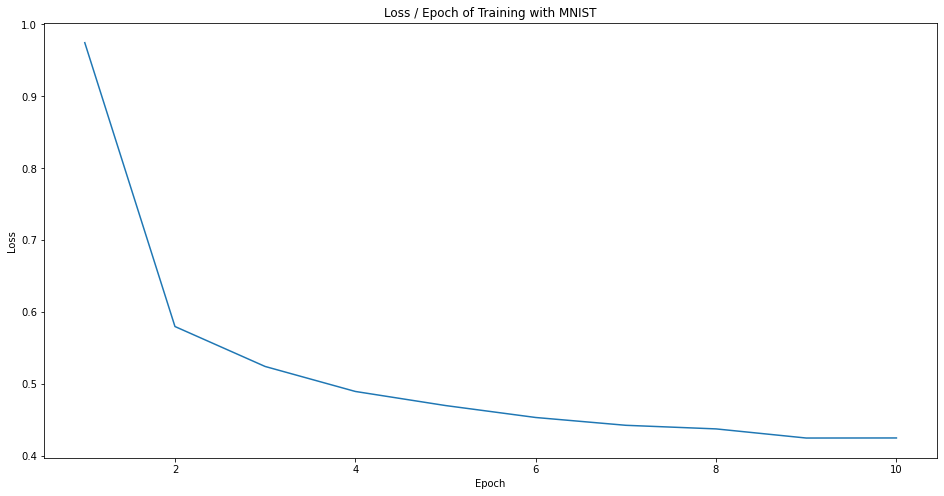

In [6]:
plt.figure(figsize=(16,8))
left = np.arange(1, num_epochs + 1)
plt.plot(left, epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss / Epoch of Training with MNIST')
plt.show()

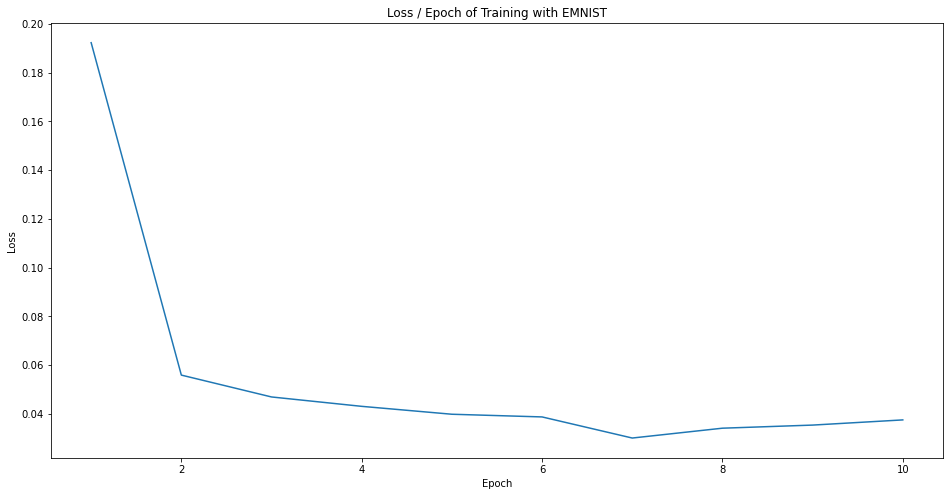

In [7]:
plt.figure(figsize=(16,8))
left = np.arange(1, num_epochs + 1)
plt.plot(left, epoch_losses_m)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss / Epoch of Training with EMNIST')
plt.show()

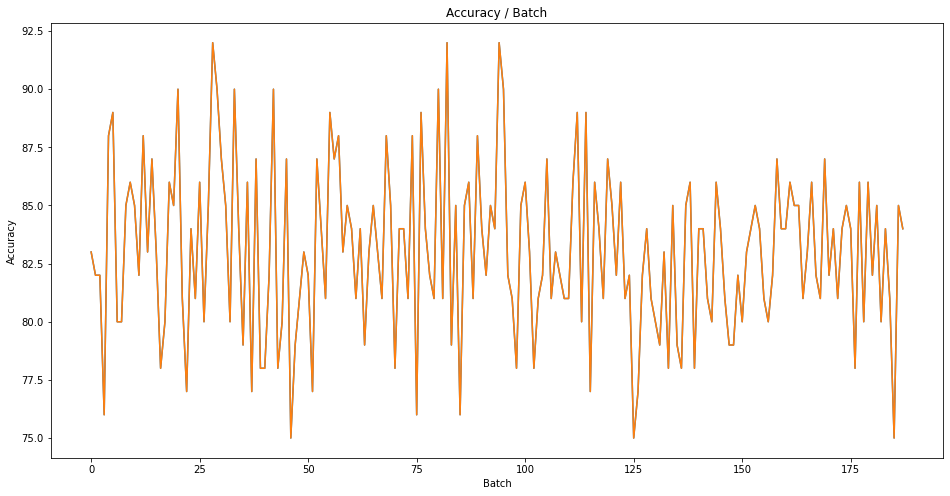

In [8]:
plt.figure(figsize=(16,8))
left = np.arange(0, num_batches) 
plt.plot(left, train_accuracies)
plt.plot(left, train_accuracies)
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('Accuracy / Batch')
plt.show()

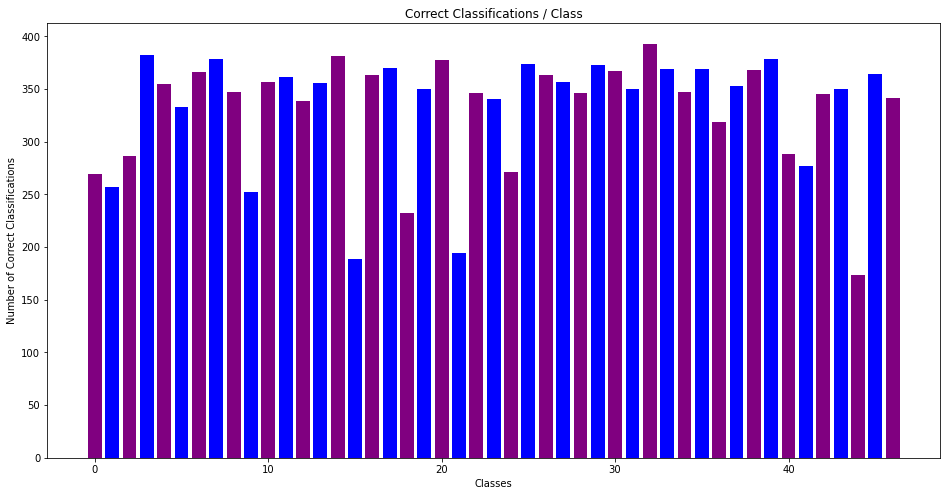

In [9]:
plt.figure(figsize=(16,8))

left = np.arange(0, num_classes) 
height = total_class_right.tolist()
plt.bar(left, height, color = ['purple', 'blue'])
plt.xlabel('Classes')
plt.ylabel('Number of Correct Classifications')
plt.title('Correct Classifications / Class')

plt.show()

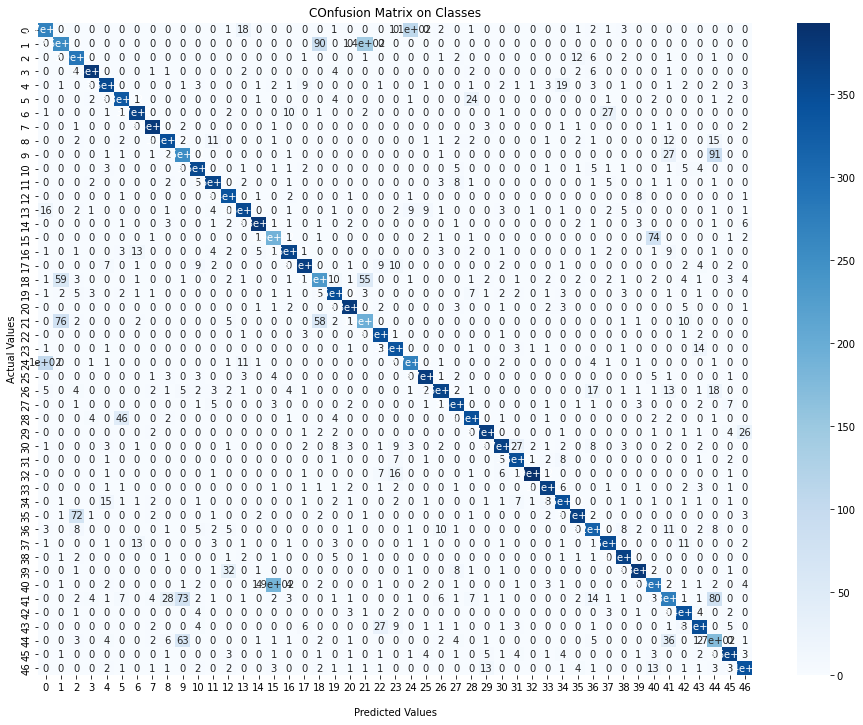

In [10]:
real_y = None
pred_y = None

for lbls in all_labels:
    if real_y is None:
        real_y = lbls
    else:  
        real_y = torch.cat((real_y, lbls), 0)

for pred in all_predictions:
    if pred_y is None:
        pred_y = torch.tensor(pred)
    else:  
        pred_y = torch.cat((pred_y, torch.tensor(pred)), 0)

plt.figure(figsize=(16,12))
cm = confusion_matrix(pred_y, real_y)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('COnfusion Matrix on Classes');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.show()

In [12]:
print(classification_report(real_y, pred_y))

              precision    recall  f1-score   support

           0       0.66      0.67      0.67       400
           1       0.53      0.64      0.58       400
           2       0.91      0.71      0.80       400
           3       0.94      0.95      0.95       400
           4       0.86      0.89      0.87       400
           5       0.90      0.83      0.86       400
           6       0.89      0.92      0.90       400
           7       0.97      0.94      0.96       400
           8       0.86      0.87      0.87       400
           9       0.67      0.63      0.65       400
          10       0.92      0.89      0.90       400
          11       0.92      0.90      0.91       400
          12       0.96      0.85      0.90       400
          13       0.85      0.89      0.87       400
          14       0.94      0.95      0.94       400
          15       0.69      0.47      0.56       400
          16       0.88      0.91      0.89       400
          17       0.88    